<a href="https://colab.research.google.com/github/karye/Liu-labbar/blob/main/Lab_2_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 - Supervised Learning

In this laboration you will explore supervised learning for classification problems. We will start with the task of flower classification. Then in the second part of the notebook we will look into *fraud detection*. We will investigate how to evaluate if a machine model works as intended, and what we can do about it if it doesn't.

**Do the labs top to bottom.**
<br />
**It is not needed to read further ahead than the current lab section.**

<br />
<hr />

### **Authors**
David Bergström<br />
Mattias Tiger, mattias.tiger@liu.se


### **License**
CC BY-NC-SA 4.0 <br />
https://creativecommons.org/licenses/by-nc-sa/4.0/

The lab (Notebook: code and instructions) is free to use, share, change and to make your own version suitable for your own students. The only restriction to this version and any new version is that 1) the same license (CC BY-NC-SA 4.0) is applied, 2) that the above mentioned authors are referred to as the authors of the original version and 3) that it cannot be used in a setting where a person or business has to pay to get access to, or in order to use, the version. I.e. full permission is given to use the lab, and subsequent versions, in schools or study circles, even running on paid-for computational resources (e.g. paid version of Google colab).
<hr />


# Supervised learning - Lab 2.0 - Introduction

First, a few words on supervised machine learning.
Supervised machine learning is a branch of machine learning, where you train or estimate a model to make predictions about outputs given inputs. The model is trained by giving it several examples of how the input and output looks, called input-output pairs.
These pair are often collected into datasets, some of which are public.

In this lab, your task is to evaluate a supervised machine learning model.
Some questions to consider:

- Analyze the results, how does the confusion matrices look? Is the result good? Why?
- Try changing the hyperparameters for the XGBoost model and see if you can get better results (Here's a list of all hyperparameters you can modify: https://xgboost.readthedocs.io/en/stable/parameter.html)


We will go through and discuss the lab together after you have done it on your own. We recommend doing it in pairs.


<hr />

# Flower classification - Lab 2.1


## Iris flower dataset

In this lab, we are going to look at the Iris flower dataset.
The dataset consists of several measurements on flowers of the Iris family.
The task for the model is to use these measurementts to predict the species of the flower. It will be used as a stand-in for say a banking transaction dataset, which is more relevant for fraud detection but also containing sentitive information.

You can read more about the Iris flower dataset here, if you are interested:

- https://archive.ics.uci.edu/ml/datasets/iris
- https://en.wikipedia.org/wiki/Iris_flower_data_set

## Importing relevant libraries

As this is a notebook, the text is interleaved with the source code.
Let's import some Python libraries we will use:

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np
import itertools
import pandas as pd

## Loading the dataset

Next, let's load the dataset.

In [ ]:
X, y = load_iris(return_X_y=True, as_frame=True)
X.rename(columns = lambda x: x.replace(' ', '_'), inplace=True)
X, y

(     sepal_length_(cm)  sepal_width_(cm)  petal_length_(cm)  petal_width_(cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 0      0
 1      0
 2   

Ok, that's not very readable. Let's put all data into a single Pandas table.

In [ ]:
all_data = X
all_data['Species'] = y
all_data

,sepal_length_(cm),sepal_width_(cm),petal_length_(cm),petal_width_(cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


Here each row corresponds to a single plant. Remember, the task of the model is to predict the species given the different measurements, which means that the model to predict the last column given the first four columns.

## Splitting the dataset

In supervised machine learning, we often deal with limited datasets.
In order to make the most out of the available data, the data is often split into three categories:

1. Training dataset: This data is used to train the model
2. Test dataset: This data is used to test the trained model
3. Validation dataset: This data is used for final validation

So what's the difference between the test and validation datasets? The key difference is that the validation dataset should only be used **once**. It is our way of measuring if the machine learning model has learned what we want and is able to generalize to new un-seen input.

Meanwhile, the training and test sets might be used several times for different models. The training set is used to train the model, the test set is used to give an indication of the degree of generalization to data from similar datasets during training. This is used to stop the training when we start to overfit to the training data.

However, if we train a large number of models and pick the model with the best performance on the test set, we risk picking the model which works best on the test set, rather than finding the model which generalizes the best. This is when the validation dataset comes in, to make a final evaluation of the model's generalization outside of the training set (and to a degree the test set).

In [ ]:
indices = np.arange(len(all_data))

rnd = np.random.default_rng(12345)
rnd.shuffle(indices)

training = int(0.8 * len(indices))
test = int(0.1 * len(indices))
validation = int(0.1 * len(indices))

training_idx = indices[:training]
test_idx = indices[training:training+test]
validation_idx = indices[training+test:]

training_x = X.iloc[training_idx]
training_y = y.iloc[training_idx]
test_x = X.iloc[test_idx]
test_y = y.iloc[test_idx]
validation_x = X.iloc[validation_idx]
validation_y = y.iloc[validation_idx]

dtrain = xgb.DMatrix(training_x, label=training_y)
dtest = xgb.DMatrix(test_x, label=test_y)
dvalidation = xgb.DMatrix(validation_x, label=validation_y)

Ok, the data is loaded into training, test and validations sets. Let's train the model!

In [ ]:
param = {'max_depth': 1, 'eta': 0.3, 'num_class': 3, 'subsample': 0.5}

num_round = 1

bst = xgb.train(param, dtrain, num_round)

Ok, now what? Let's see how well it can do predictions on the test set.

In [ ]:
test_predictions = bst.predict(dtest)

test_predictions

array([1., 1., 1., 0., 1., 2., 1., 2., 0., 2., 0., 0., 2., 0., 1.],
      dtype=float32)

How are these misspredictions distributed? Is the model equally good for all classes, or is it better on one class than the others?

**Note:** This relates to fairness, where the model might be incentivized to predict well on the majority of the data, which could come at the cost of performancy on the remaining minority. If this data is somehow related to people, pre-existing biases might be preserved or even amplified in the resulting model.

One way to get a better overview of the result is to look at a confusion matrix. Here is the source code to plot a confusion matrix:

In [ ]:
def plot_confusion(predictions, truth, label, classes):

  confusion = np.zeros((len(classes), len(classes)), dtype=int)

  for prediction, truth in zip(predictions, truth):
    prediction = int(prediction)
    confusion[truth, prediction] += 1

  plt.figure()
  plt.imshow(confusion, interpolation="nearest", cmap='Blues')
  title = f'Confusion matrix, for {label} data'
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)
  normalize = False
  fmt = '.2f' if normalize else 'd'
  thresh = confusion.max() / 2.
  for i, j in itertools.product(range(confusion.shape[0]), range(confusion.shape[1])):
      plt.text(j, i, format(confusion[i, j], fmt),
              horizontalalignment="center",
              color="white" if confusion[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()
  plt.show()

And here are the resulting confusion matrices, first for the training dataset and second for the test dataset.

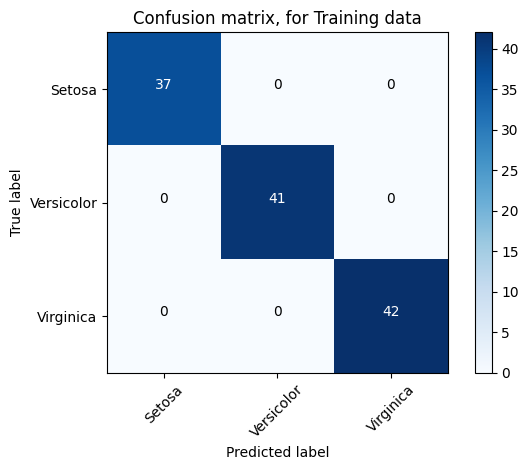

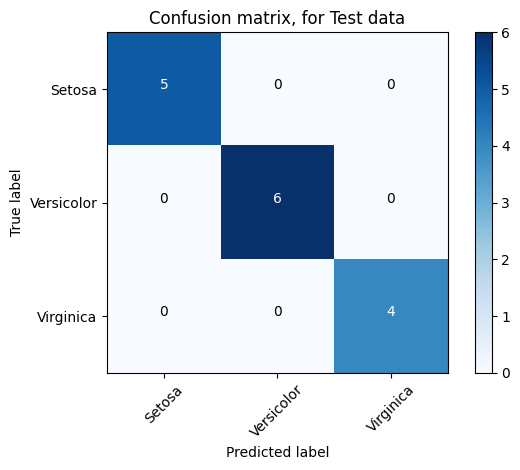

In [ ]:
training_predictions = bst.predict(dtrain)
test_predictions = bst.predict(dtest)

plot_confusion(training_predictions, training_y, 'Training', classes=['Setosa', 'Versicolor', 'Virginica'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Setosa', 'Versicolor', 'Virginica'])

The most basic form of evaluation is counting the number of times the model got it right.

In [ ]:
print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 100.00%


The above is the average accuracy, meaning that the model got 100% correct answers! Non-of the three flower types were miss-classified. This is rare when using machine learning in practice.

Now, let's look at a more complicated dataset.

# Fraud Detection - Lab 2.2

We will be using a dataset on credit card usage from an international competition in fraud detection.

Read through the description here (Content and Context): [https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Now, lets load the data set and have a look.

In [ ]:
fraud = pd.read_csv('https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/refs/heads/master/creditcard.csv')

In [ ]:
fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Lets divide the data set into training, test and validation sets.

In [ ]:
indices = np.arange(len(fraud))

rnd = np.random.default_rng(12345)
rnd.shuffle(indices)

training = int(0.8 * len(indices))
test = int(0.1 * len(indices))
validation = int(0.1 * len(indices))

training_idx = indices[:training]
test_idx = indices[training:training+test]
validation_idx = indices[training+test:]

training_x = fraud.iloc[training_idx].drop(columns=['Class'])
training_y = fraud.iloc[training_idx]['Class']
test_x = fraud.iloc[test_idx].drop(columns=['Class'])
test_y = fraud.iloc[test_idx]['Class']
validation_x = fraud.iloc[validation_idx].drop(columns=['Class'])
validation_y = fraud.iloc[validation_idx]['Class']

dtrain = xgb.DMatrix(training_x, label=training_y)
dtest = xgb.DMatrix(test_x, label=test_y)
dvalidation = xgb.DMatrix(validation_x, label=validation_y)

How do we as humans know if a row in the table is a fraud or not? (I.e. how is this information represented in the table right now.)

<hr />

Let's train the model!

In [ ]:
#Here are some parameters I found online. Should work, right?
param = {'objective': 'binary:logistic', 'max_depth': 1, 'eta': 0.3, 'subsample': 0.5}
num_round = 1

bst = xgb.train(param, dtrain, num_round)

Let's see how well it performes on the test set.

In [ ]:
test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 99.35%


Great! We got very high accuracy. Almost perfect!

This would for sure be a great fraud detection system for my bank.

Let's look at the confusion matrices, just to be sure:

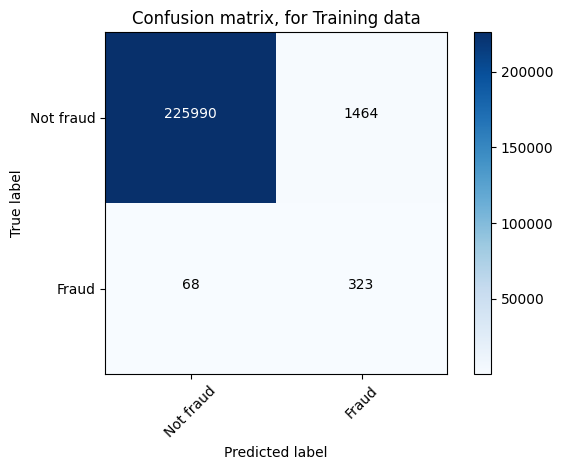

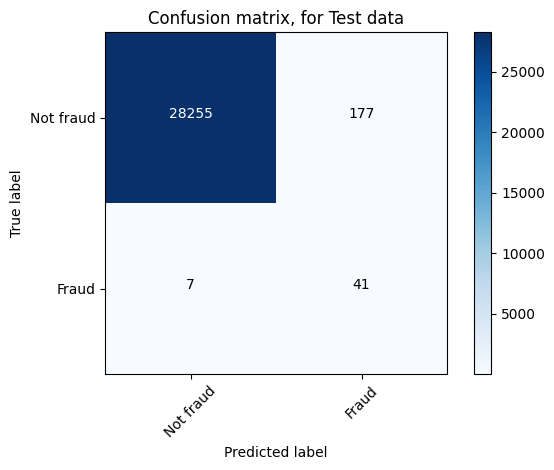

In [ ]:
training_predictions = bst.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)

test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)


plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

The test set is used to evaluate how an AI system will behave when deployed and see new data (i.e. evaluation of generalization). Based on the confusion matrix of the test data:

1. What does this mean for customers who are victims of fraud?
  * If you are a victim of fraud, what is the probability that the fraud detector will identify the fraud and save you, based on the confusion matrix for the test data?


2. What does this mean for customers who aren't?
  * If you want to make a purchase, what is the probability that the fraud detector will falsely classify your transaction as fradulent? E.g. blocking your legitimate transaction.

3. What do you think about this result?
  * Would you like that your current bank deploy this fraud detector?




---
Let's train the model again, but with slightly better choice of parameters
(train longer and with a deeper model).

In [ ]:
param = {'objective': 'binary:logistic', 'max_depth': 6, 'eta': 0.3, 'subsample': 0.5}

num_round = 10

bst = xgb.train(param, dtrain, num_round)

Let's see how well it performes on the test set.


In [ ]:
test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 99.83%


Great! We got very high accuracy (even higher than previously)! Let's take a look at the confusion matrices:

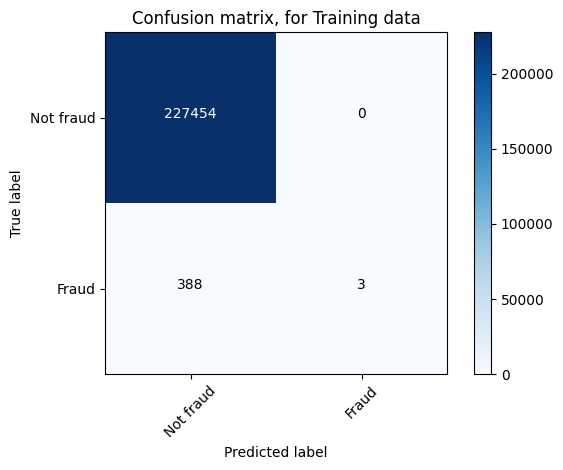

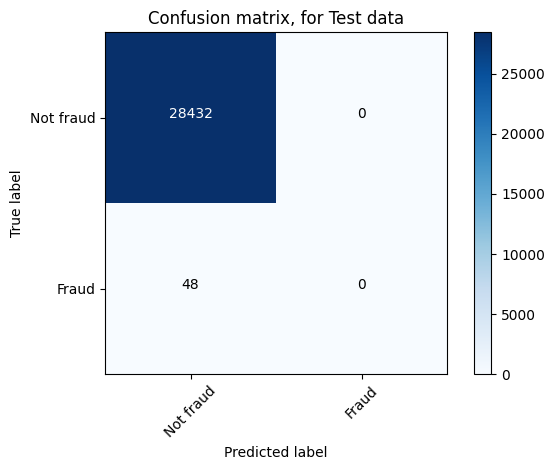

In [ ]:
training_predictions = bst.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)

test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)


plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

The test set is used to evaluate how an AI system will behave when deployed and see new data (i.e. evaluation of generalization). Based on the confusion matrix of the test data:

1. What does this mean for customers who are victims of fraud?
  * If you are a victim of fraud, what is the probability that the fraud detector will identify the fraud and save you, based on the confusion matrix for the test data?


2. What does this mean for customers who aren't?
  * If you want to make a purchase, what is the probability that the fraud detector will falsely classify your transaction as fradulent? E.g. blocking your legitimate transaction.

3. What do you think about this result?
  * Would you like that your current bank deploy this fraud detector?

# Fraud Detection - Lab 2.3: Re-balancing the training

So, as we could see in the confusion matrix, almost all the data (almost all rows in the data table) are non-fraud. So guessing that an input is "not fraud" for **all input** (no matter the input) give the model high accuracy, but then it isn't really solving the problem of detecting fraud..

Even when we trained a deeper model for longer, we still have a large probability of missclassifying a fraudulant transaction as beeing non-fraud.

So, how can we fix this? For starter, we can try an re-balance the data set so that we have an equal amount of fraud and non-fraud data points (rows in the table).

First, how unbalanced is the dataset?

In [ ]:
n_fraud = (training_y == 1).sum()
print(n_fraud, 'cases of fraud.')

n_not_fraud = (training_y == 0).sum()
print(n_not_fraud, 'cases of where no fraud happend.')

print("The fraction of the data which is not fraud is", n_not_fraud/(n_not_fraud + n_fraud))



391 cases of fraud.
227454 cases of where no fraud happend.
The fraction of the data which is not fraud is 0.9982839210867037


How many 'fraud'-samples are there for each 'non-fraud' sample?

In [ ]:
scale = n_not_fraud / n_fraud
print("There are", scale, "'fraud'-samples for every 'non-fraud'-sample")

There are 581.7237851662404 'fraud'-samples for every 'non-fraud'-sample


<hr />

We now have a scale factor (the fraction above) that can be used when training the machine learning model. It will allow the training procedure to know how often it should re-use training data-points of the under-represented class (no-fraud in this case) to make it balanced.

Let's train using this scale factor to make the training balanced.

In [ ]:
param = {'objective': 'binary:logistic', 'max_depth': 6, 'eta': 0.3, 'subsample': 0.5, 'scale_pos_weight': float(scale)} #scale_pos_weight används aldrig
# MATTIAS - DEBUG
# scale_pos_weight används aldrig även om den sätts som param.

# param = {'objective': 'binary:logistic', 'max_depth': 6, 'eta': 0.3, 'subsample': 0.5}

num_round = 10

bst = xgb.train(param, dtrain, num_round)

In [ ]:
test_predictions = bst.predict(dtest)

print('Predictions are between 0.0 and 1.0: ', test_predictions)

test_predictions = 1 * (test_predictions > 0.5)

print('Threasholding to get predictions to be either 0 or 1: ', test_predictions)
print('')
print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Predictions are between 0.0 and 1.0:  [0.05251941 0.02415858 0.01988412 ... 0.02177255 0.0407142  0.02177255]
Threasholding to get predictions to be either 0 or 1:  [0 0 0 ... 0 0 0]

Test Accuracy: 99.46%


Now, what does the confusion matrix for the model look like when training the model like this?

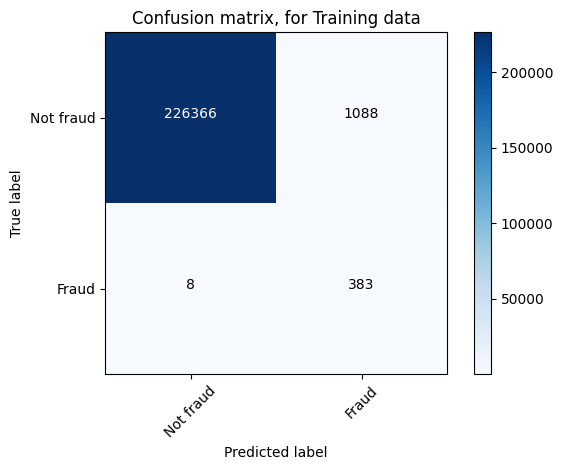

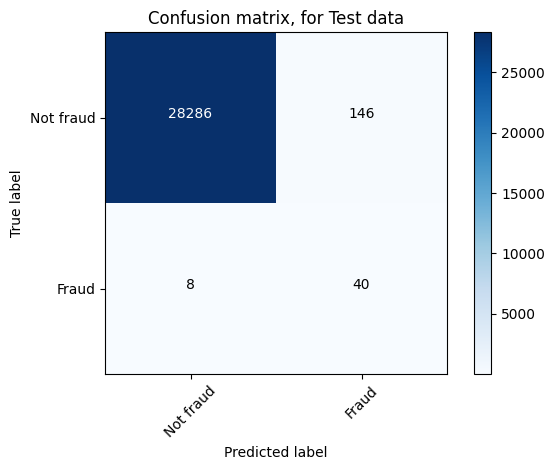

In [ ]:
training_predictions = bst.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)
test_predictions = bst.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

Ok, this is better. We missed fewer fraud cases.

1. What does this mean for customers who are victims of fraud?
  * If you are a victim of fraud, what is the probability that the fraud detector will identify the fraud and save you, based on the confusion matrix for the test data?

2. What does this mean for customers who aren't?
  * If you want to make a purchase, what is the probability that the fraud detector will falsely classify your transaction as fradulent? E.g. blocking your legitimate transaction.

  
3. What do you think about this result?
  * Would you like that your current bank deploy this fraud detector?

# Fraud Detection - Lab 2.4: Hyperparameter Tuning (false negatives)

Considering the application, there are certain cases (e.g. quadrants in the confusion matrix) that are much more important to be correct about than others. How can we train the machine learning model while prioritizing different such cases? Let's find out!

Let's pick false negatives (down-left quadrant) as something we want to be better at. This means that we want to reduce the number of actual frauds that we mistakenly classify as being non-fraud. Right now there are 9 of such cases in the test-data.

What can we do if we only care about the false negatives, i.e. when we missclassify a fraud as not being fraud? That is, we want the model to be maximally good at this specific case. One option is to do hyperparameter tuning. That is, to adjust paramters that specify how the learning takes place for our machine learning model.

In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

We start by defining what we want to achieve. We want to have few false positives, confusion[1, 0]. Lets specify that we consider 1 false positive to be worth 100 times that of a false negative (classifying as fraud but it is not in fact fraud).

In [ ]:
def objective_fn(params):
    # eta, max_depth, subsample, colsample_bytree, colsample_bylevel, min_child_weight, alpha, lambda_, gamma, scale_pos_weight = params
    eta, max_depth, subsample, colsample_bytree, colsample_bylevel, min_child_weight, alpha, lambda_, gamma = params
    num_round=10
    model = xgb.train(
        {
            'objective': 'binary:logistic',
            'eta': eta,
            'max_depth': max_depth,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'colsample_bylevel': colsample_bylevel,
            'alpha': alpha,
            'lambda': lambda_,
            'gamma': gamma,
            'scale_pos_weigth': float(scale),
            'nthread': 1,
        },
        dtrain,
        num_round)
    test_predictions = model.predict(dtest)

    confusion = np.zeros((2, 2), dtype=int)

    for prediction, truth in zip(test_predictions, test_y):
        prediction = 1 * (prediction > 0.5)
        confusion[truth, prediction] += 1

    loss = confusion[1, 0] * 10000 + confusion[0, 1] * 100

    # Return the number of false negatives
    return {'loss': loss, 'model': model, 'status': STATUS_OK}


In [ ]:
trials = Trials()

We will now find the best learning parameters (hyperparameters) which minimize the loss (false-positives), and we do this according to a prior probability distribution over the values over the different learning parameters.

How we do it is via Bayesian Optimization, which is a combination of optimization and machine learning. It is very efficient, requirering only a few trials (we use 100 here) to find a really good learning parameter configuration.

In [ ]:
best = fmin(objective_fn,
            space=[hp.loguniform('eta', np.e**-7, 1),
                1 + hp.randint('max_depth', 9),
                hp.uniform('subsample', 0.2, 1),
                hp.uniform('colsample_bytree', 0.2, 1),
                hp.uniform('colsample_bylevel', 0.2, 1),
                hp.loguniform('min_child_weight', np.e**-16, np.e**5),
                hp.choice('alpha', [0, hp.loguniform('a', np.e**-16, np.e**2)]),
                hp.choice('lambda', [0, hp.loguniform('l', np.e**-16, np.e**2)]),
                hp.choice('gamma', [0, hp.loguniform('g', np.e**-16, np.e**2)]),
                #  hp.uniform('scale_pos_weight', 0, 1),
                ],
            algo=tpe.suggest,
            max_evals=100,
            trials=trials,
            rstate=np.random.seed(12345))

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:28:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  1%|          | 1/100 [00:00<00:47,  2.06trial/s, best loss: 480000.0]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:28:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  5%|▌         | 5/100 [00:01<00:25,  3.65trial/s, best loss: 144400.0]

...

 94%|█████████▍| 94/100 [00:34<00:02,  2.85trial/s, best loss: 82200.0]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:29:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 97%|█████████▋| 97/100 [00:35<00:00,  3.09trial/s, best loss: 82200.0]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:29:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weigth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



100%|██████████| 100/100 [00:36<00:00,  2.77trial/s, best loss: 82200.0]


Now we select the best model that we found (i.e. the one with the best learning parameters found).

In [ ]:
i = np.argmin(trials.losses())
best = trials.results[i]

best_model = best['model']

# Extract predictions and calculate the test accuracy
training_predictions = best_model.predict(dtrain)
training_predictions = 1 * (training_predictions > 0.5)
test_predictions = best_model.predict(dtest)
test_predictions = 1 * (test_predictions > 0.5)

print(f'Test Accuracy: {(test_predictions == test_y).mean():.2%}')

Test Accuracy: 99.89%


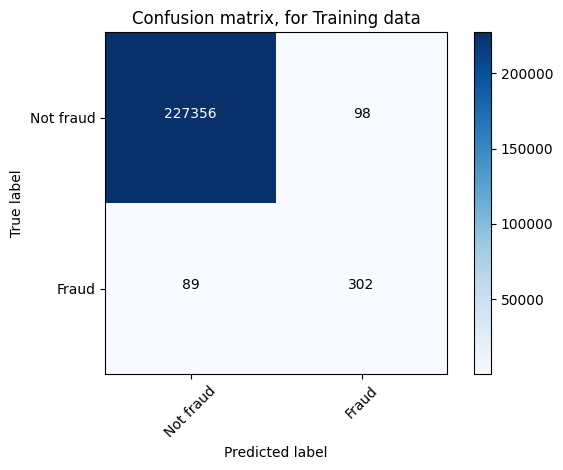

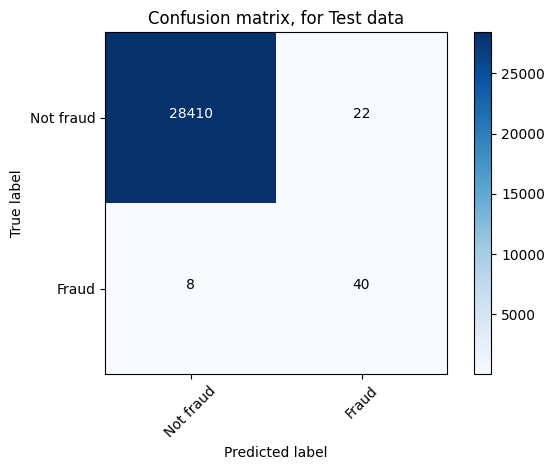

In [ ]:
plot_confusion(training_predictions, training_y, 'Training', classes=['Not fraud', 'Fraud'])
plot_confusion(test_predictions, test_y, 'Test', classes=['Not fraud', 'Fraud'])

How much better did it get?

1. What does this mean for customers who are victims of fraud?
  * If you are a victim of fraud, what is the probability that the fraud detector will identify the fraud and save you, based on the confusion matrix for the test data?

2. What does this mean for customers who aren't?
  * If you want to make a purchase, what is the probability that the fraud detector will falsely classify your transaction as fradulent? E.g. blocking your legitimate transaction.

3. What do you think about this result?
  * Would you like that your current bank deploy this fraud detector?

4. What conclusions can you draw from this lab regarding the relationship between accuracy and business value?